In [ ]:
import os

# Disable all WandB logging
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"


In [ ]:
trainer.train()


NameError: name 'trainer' is not defined

In [1]:
# =========================
# 1. Install / imports
# =========================
!pip install -q -U transformers datasets accelerate scikit-learn

import os
import re
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

# Optional: keep logging quiet
os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

set_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 146.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.5 MB/s eta 0:00:00
Torch: 2.10.0+cu128
CUDA available: True
Device: cuda


In [3]:
# =========================
# 2. Upload dataset
# =========================
from google.colab import files
uploaded = files.upload()   # choose covmis_stance.csv

Saving covmis_stance.csv to covmis_stance.csv


In [4]:
# =========================
# 3. Load and preprocess
# =========================
df = pd.read_csv("covmis_stance.csv")

def simplify_label(stance):
    stance = str(stance).lower()
    if stance == "favor":
        return "misinfo"
    elif stance in ["against", "neither"]:
        return "not_misinfo"
    return None

def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

# Filter for vaccine-related tweets
vaccine_keywords = ["vaccine", "pfizer", "moderna", "booster", "jab", "shot", "astrazeneca"]
mask = df["mis"].astype(str).str.lower().str.contains("|".join(vaccine_keywords), na=False)
df = df[mask].copy()

# Simplify labels + clean text
df["label_simplified"] = df["label"].apply(simplify_label)
df = df.dropna(subset=["label_simplified"])
df["text_cleaned"] = df["mis"].apply(clean_text)

print(df["label_simplified"].value_counts())
print("Total samples:", len(df))

# Encode labels
label2id = {"misinfo": 0, "not_misinfo": 1}
id2label = {0: "misinfo", 1: "not_misinfo"}
df["label_id"] = df["label_simplified"].map(label2id)

# Keep only needed columns
df_model = df[["text_cleaned", "label_id"]].rename(columns={"label_id": "label"})
df_model.head()

label_simplified
not_misinfo    80
misinfo        59
Name: count, dtype: int64
Total samples: 139


,text_cleaned,label
180,bill gates is plotting to use covid-19 testing...,0
181,bill gates is plotting to use covid-19 testing...,1
182,bill gates is plotting to use covid-19 testing...,0
183,bill gates is plotting to use covid-19 testing...,1
184,bill gates is plotting to use covid-19 testing...,1


In [5]:
# =========================
# 4. Train/val/test split
# =========================
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    stratify=df_model["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 97
Val: 21
Test: 21


In [6]:
# =========================
# 5. Convert to HF datasets
# =========================
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

In [7]:
# =========================
# 6. Tokenizer + tokenization
# =========================
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(
        batch["text_cleaned"],
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned"])
val_ds = val_ds.remove_columns(["text_cleaned"])
test_ds = test_ds.remove_columns(["text_cleaned"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/421 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/97 [00:00<?, ? examples/s]

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

In [8]:
# =========================
# 7. Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

In [9]:
# =========================
# 8. Model
# =========================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: digitalepidemiologylab/covid-twitter-bert-v2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

In [10]:
# =========================
# 9. Training arguments
# =========================
args = TrainingArguments(
    output_dir="./ctbert_results",
    eval_strategy="epoch",          # works with your newer version path
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

In [23]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.641163,0.444371,0.857143,0.860577,0.847222,0.851765
2,0.663859,0.549003,0.523810,0.500000,0.500000,0.495192
3,0.570044,0.490746,0.666667,0.663636,0.666667,0.663616


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=39, training_loss=0.625021714430589, metrics={'train_runtime': 34.3562, 'train_samples_per_second': 16.94, 'train_steps_per_second': 2.27, 'total_flos': 18028867487820.0, 'train_loss': 0.625021714430589, 'epoch': 3.0})

In [20]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load pretrained model and tokenizer
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at digitalepidemiologylab/covid-twitter-bert-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

print("=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=["misinfo", "not_misinfo"],
    zero_division=0
))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

     misinfo       0.46      0.67      0.55         9
 not_misinfo       0.62      0.42      0.50        12

    accuracy                           0.52        21
   macro avg       0.54      0.54      0.52        21
weighted avg       0.55      0.52      0.52        21


=== Confusion Matrix ===
[[6 3]
 [7 5]]


In [27]:
pred_output = trainer.predict(test_ds)

In [28]:
# =========================
# 11. Train
# =========================
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.605740,0.497483,0.809524,0.813636,0.819444,0.809091
2,0.646227,0.461879,0.761905,0.777778,0.777778,0.761905
3,0.543245,0.481701,0.857143,0.860577,0.847222,0.851765
4,0.594232,0.496588,0.761905,0.783333,0.736111,0.740741
5,0.575527,0.500046,0.761905,0.783333,0.736111,0.740741


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=65, training_loss=0.5929944258469801, metrics={'train_runtime': 56.8432, 'train_samples_per_second': 10.239, 'train_steps_per_second': 1.372, 'total_flos': 30751914811380.0, 'train_loss': 0.5929944258469801, 'epoch': 5.0})

In [30]:
from transformers.utils.notebook import NotebookProgressCallback
from transformers import ProgressCallback

# remove the notebook callback that is causing the state error
trainer.remove_callback(NotebookProgressCallback)

# add normal progress callback instead
trainer.add_callback(ProgressCallback)

In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

print("=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=["misinfo", "not_misinfo"],
    zero_division=0
))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))

  0%|          | 0/3 [00:00<?, ?it/s]

=== Classification Report ===
              precision    recall  f1-score   support

     misinfo       0.46      0.67      0.55         9
 not_misinfo       0.62      0.42      0.50        12

    accuracy                           0.52        21
   macro avg       0.54      0.54      0.52        21
weighted avg       0.55      0.52      0.52        21


=== Confusion Matrix ===
[[6 3]
 [7 5]]


In [32]:
from transformers import Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback

args = TrainingArguments(
    output_dir="./ctbert_results_clean",
    eval_strategy="no",
    save_strategy="no",
    logging_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",
    disable_tqdm=True,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# make sure notebook callback is gone
trainer.remove_callback(NotebookProgressCallback)

In [33]:
pred_output = trainer.predict(test_ds)

In [34]:
# =========================
# 12. Evaluate on validation
# =========================
val_metrics = trainer.evaluate()
print("Validation metrics:")
print(val_metrics)

{'eval_loss': '0.4817', 'eval_model_preparation_time': '0.0083', 'eval_accuracy': '0.8571', 'eval_macro_precision': '0.8606', 'eval_macro_recall': '0.8472', 'eval_macro_f1': '0.8518', 'eval_runtime': '0.0958', 'eval_samples_per_second': '219.2', 'eval_steps_per_second': '31.31', 'epoch': 0}
Validation metrics:
{'eval_loss': 0.48165449500083923, 'eval_model_preparation_time': 0.0083, 'eval_accuracy': 0.8571428571428571, 'eval_macro_precision': 0.8605769230769231, 'eval_macro_recall': 0.8472222222222222, 'eval_macro_f1': 0.851764705882353, 'eval_runtime': 0.0958, 'eval_samples_per_second': 219.15, 'eval_steps_per_second': 31.307, 'epoch': 0}


In [35]:
# =========================
# 13. Final test predictions
# =========================
pred_output = trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"], zero_division=0))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

     misinfo       0.46      0.67      0.55         9
 not_misinfo       0.62      0.42      0.50        12

    accuracy                           0.52        21
   macro avg       0.54      0.54      0.52        21
weighted avg       0.55      0.52      0.52        21

=== Confusion Matrix ===
[[6 3]
 [7 5]]


In [36]:
# =========================
# 14. Save model
# =========================
trainer.save_model("./covid_ctbert_best")
tokenizer.save_pretrained("./covid_ctbert_best")
print("Saved to ./covid_ctbert_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./covid_ctbert_best


In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd
from transformers import AutoTokenizer

# 1️⃣ Load your pilot dataset
proc_dir = "./data_processed"
df = pd.read_csv(f"{proc_dir}/pilot_labels.csv")

# 2️⃣ Encode labels
label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)

# 3️⃣ Split into train/test
train_df, test_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["label"]
)

# 4️⃣ Convert to Hugging Face Dataset format
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# 5️⃣ Tokenize
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text_cleaned"], truncation=True, padding="max_length", max_length=128
    )

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])

train_ds.set_format("torch")
test_ds.set_format("torch")

print("✅ train_ds and test_ds ready.")


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ train_ds and test_ds ready.


In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.693500,0.694809
2,0.705400,0.700316
3,0.667400,0.721400


TrainOutput(global_step=33, training_loss=0.6991865851662376, metrics={'train_runtime': 22.6141, 'train_samples_per_second': 11.674, 'train_steps_per_second': 1.459, 'total_flos': 61507469979648.0, 'train_loss': 0.6991865851662376, 'epoch': 3.0})

In [ ]:
import pandas as pd

df = pd.read_csv(f"{raw_dir}/covmis_stance.csv")

# Vaccine keywords
vaccine_keywords = ["vaccine", "pfizer", "moderna", "booster", "jab", "shot", "astrazeneca"]

# Use the correct text column 'mis'
mask = df["mis"].astype(str).str.lower().str.contains("|".join(vaccine_keywords), na=False)
df_vaccine = df[mask].copy()

print("Original dataset size:", len(df))
print("Vaccine-related subset:", len(df_vaccine))
df_vaccine.head(5)



Original dataset size: 2631
Vaccine-related subset: 139


,source,mid,mis,tweet_id,label,auto
180,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1348735494973231107,favor,False
181,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1293198086257270784,neither,False
182,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1356414381450555394,favor,False
183,fact_check_url,69,Bill Gates is plotting to use COVID-19 testing...,1250476434704957444,against,True
184,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1251168990526869506,against,False


In [ ]:
# Simplify stances into two categories
def simplify_label(stance):
    stance = str(stance).lower()
    if stance in ["favor"]:      # supports the misinformation
        return "misinfo"
    elif stance in ["against", "neither"]:  # disagrees or neutral
        return "not_misinfo"
    else:
        return None

df_vaccine["label_simplified"] = df_vaccine["label"].apply(simplify_label)

# Drop missing or undefined labels
df_vaccine = df_vaccine.dropna(subset=["label_simplified"])

print(df_vaccine["label_simplified"].value_counts())
df_vaccine.head(5)



label_simplified
not_misinfo    80
misinfo        59
Name: count, dtype: int64


,source,mid,mis,tweet_id,label,auto,label_simplified
180,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1348735494973231107,favor,False,misinfo
181,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1293198086257270784,neither,False,not_misinfo
182,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1356414381450555394,favor,False,misinfo
183,fact_check_url,69,Bill Gates is plotting to use COVID-19 testing...,1250476434704957444,against,True,not_misinfo
184,keywords,69,Bill Gates is plotting to use COVID-19 testing...,1251168990526869506,against,False,not_misinfo


In [ ]:
import re

# 1️⃣ Clean tweet text
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))       # remove URLs
    text = re.sub(r"@\w+", "", text)               # remove mentions
    text = re.sub(r"#", "", text)                  # remove hashtag symbol
    text = re.sub(r"\s+", " ", text).strip()       # remove extra spaces
    return text.lower()

df_vaccine["text_cleaned"] = df_vaccine["mis"].apply(clean_text)

# 2️⃣ Balance classes (use equal counts)
n = min(df_vaccine["label_simplified"].value_counts().min(), 59)  # smallest class count
df_balanced = (
    df_vaccine.groupby("label_simplified", group_keys=False)
    .apply(lambda x: x.sample(n=n, random_state=42))
    .reset_index(drop=True)
)

# 3️⃣ Save the pilot dataset
df_balanced = df_balanced[["text_cleaned", "label_simplified"]]
print(df_balanced["label_simplified"].value_counts())

# 4️⃣ Write to Google Drive for later use
df_balanced.to_csv(f"{proc_dir}/pilot_labels.csv", index=False)

print(f"✅ Pilot dataset saved to: {proc_dir}/pilot_labels.csv")
df_balanced.head(5)


label_simplified
misinfo        59
not_misinfo    59
Name: count, dtype: int64
✅ Pilot dataset saved to: ./data_processed/pilot_labels.csv


/tmp/ipython-input-2686788680.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n, random_state=42))


,text_cleaned,label_simplified
0,bill gates is plotting to use covid-19 testing...,misinfo
1,bill gates is plotting to use covid-19 testing...,misinfo
2,"flu vaccine increases coronavirus risk 36%, sa...",misinfo
3,covid-19 vaccine trial killed 7 children in se...,misinfo
4,"flu vaccine increases coronavirus risk 36%, sa...",misinfo


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Load the cleaned pilot dataset
pilot_path = f"{proc_dir}/pilot_labels.csv"
df = pd.read_csv(pilot_path)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df["text_cleaned"], df["label_simplified"], test_size=0.25, random_state=42, stratify=df["label_simplified"]
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=200, class_weight='balanced')
model.fit(X_train_vec, y_train)

# Evaluate
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

     misinfo       0.60      1.00      0.75        15
 not_misinfo       1.00      0.33      0.50        15

    accuracy                           0.67        30
   macro avg       0.80      0.67      0.62        30
weighted avg       0.80      0.67      0.62        30


Confusion Matrix:
[[15  0]
 [10  5]]


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 5, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [200, 400]
}

grid = GridSearchCV(LogisticRegression(class_weight='balanced'), params, cv=3, scoring='f1_macro')
grid.fit(X_train_vec, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_vec)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Best Params: {'C': 0.1, 'max_iter': 200, 'solver': 'liblinear'}
              precision    recall  f1-score   support

     misinfo       0.60      1.00      0.75        15
 not_misinfo       1.00      0.33      0.50        15

    accuracy                           0.67        30
   macro avg       0.80      0.67      0.62        30
weighted avg       0.80      0.67      0.62        30

[[15  0]
 [10  5]]


In [ ]:
!pip install transformers torch tqdm

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
import pandas as pd

# Load pilot dataset
df = pd.read_csv(f"{proc_dir}/pilot_labels.csv")

# Encode labels
label2id = {'misinfo': 0, 'not_misinfo': 1}
df['label'] = df['label_simplified'].map(label2id)

# Split train/test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df['label'])

# Convert to HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# Load tokenizer & model
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])
train_ds.set_format("torch")
test_ds.set_format("torch")

# Training setup
args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=5,
    learning_rate=2e-5,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)

trainer.train()

# Evaluate
preds = trainer.predict(test_ds)
pred_labels = preds.predictions.argmax(-1)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_df["label"], pred_labels, target_names=label2id.keys()))
print(confusion_matrix(test_df["label"], pred_labels))


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at digitalepidemiologylab/covid-twitter-bert-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch, pandas as pd
from sklearn.model_selection import train_test_split


KeyboardInterrupt: 

In [ ]:
!pip install -U transformers


In [ ]:
import transformers
print(transformers.__version__)


In [ ]:
!pip install -U transformers torch datasets tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch, pandas as pd


In [ ]:
import torch, transformers
print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


In [ ]:
args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=5,
    learning_rate=2e-5,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)

trainer.train()


In [ ]:
args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=5,
    learning_rate=2e-5,
    weight_decay=0.01
)


In [ ]:
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",       # ✅ new name in v4.57+
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=5,
    learning_rate=2e-5,
    weight_decay=0.01
)


In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)
trainer.train()


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "digitalepidemiologylab/covid-twitter-bert-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


In [ ]:
trainer.train()


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch, pandas as pd
from sklearn.model_selection import train_test_split

# 1️⃣ Load your pilot dataset
proc_dir = "./data_processed"  # adjust if needed
df = pd.read_csv(f"{proc_dir}/pilot_labels.csv")

# 2️⃣ Encode labels
label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)

# 3️⃣ Split train/test
train_df, test_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["label"]
)

# 4️⃣ Convert to Hugging Face Dataset format
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# 5️⃣ Tokenize
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)
train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])
train_ds.set_format("torch")
test_ds.set_format("torch")

# 6️⃣ Load model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# 7️⃣ Training setup (updated syntax for v4.57.1)
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # ✅ correct for Transformers 4.57+
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=5,
    learning_rate=2e-5,
    weight_decay=0.01
)

# 8️⃣ Create trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)

# 9️⃣ Train model
trainer.train()


In [ ]:
import os

print("Contents of current directory:", os.listdir("."))
if os.path.exists("data_processed"):
    print("Files in data_processed:", os.listdir("data_processed"))
else:
    print("❌ 'data_processed' folder not found.")


In [ ]:
import os, re, pandas as pd

raw_dir = "data_raw"
proc_dir = "data_processed"
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(proc_dir, exist_ok=True)

# Load the main dataset
df = pd.read_csv(f"{raw_dir}/covmis_stance.csv")

# Filter for vaccine-related tweets
vaccine_keywords = ["vaccine", "pfizer", "moderna", "booster", "jab", "shot", "astrazeneca"]
mask = df["mis"].astype(str).str.lower().str.contains("|".join(vaccine_keywords), na=False)
df_vaccine = df[mask].copy()

# Simplify stances into two categories
def simplify_label(stance):
    stance = str(stance).lower()
    if stance == "favor":
        return "misinfo"
    elif stance in ["against", "neither"]:
        return "not_misinfo"
    else:
        return None

df_vaccine["label_simplified"] = df_vaccine["label"].apply(simplify_label)
df_vaccine = df_vaccine.dropna(subset=["label_simplified"])

# Clean text
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df_vaccine["text_cleaned"] = df_vaccine["mis"].apply(clean_text)

# Balance dataset
n = min(df_vaccine["label_simplified"].value_counts().min(), 59)
df_balanced = (
    df_vaccine.groupby("label_simplified", group_keys=False)
    .apply(lambda x: x.sample(n=n, random_state=42))
    .reset_index(drop=True)
)
df_balanced = df_balanced[["text_cleaned", "label_simplified"]]

# Save pilot dataset
df_balanced.to_csv(f"{proc_dir}/pilot_labels.csv", index=False)
print(f"✅ Pilot dataset created at: {proc_dir}/pilot_labels.csv")


In [ ]:
!ls -R


In [ ]:
from google.colab import files
uploaded = files.upload()  # choose covmis_stance.csv from your device


In [ ]:
import shutil
shutil.move("covmis_stance.csv", "data_raw/covmis_stance.csv")


In [ ]:
!ls -lh data_raw


In [ ]:
import pandas as pd

df = pd.read_csv("data_raw/covmis_stance.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


In [ ]:
import re, os

raw_dir = "data_raw"
proc_dir = "data_processed"

os.makedirs(proc_dir, exist_ok=True)

# Filter for vaccine-related tweets
vaccine_keywords = ["vaccine", "pfizer", "moderna", "booster", "jab", "shot", "astrazeneca"]
mask = df["mis"].astype(str).str.lower().str.contains("|".join(vaccine_keywords), na=False)
df_vaccine = df[mask].copy()

# Simplify stance labels
def simplify_label(stance):
    stance = str(stance).lower()
    if stance == "favor":
        return "misinfo"
    elif stance in ["against", "neither"]:
        return "not_misinfo"
    return None

df_vaccine["label_simplified"] = df_vaccine["label"].apply(simplify_label)
df_vaccine = df_vaccine.dropna(subset=["label_simplified"])

# Clean text
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df_vaccine["text_cleaned"] = df_vaccine["mis"].apply(clean_text)

# Balance and save pilot dataset
n = min(df_vaccine["label_simplified"].value_counts().min(), 59)
df_balanced = df_vaccine.groupby("label_simplified", group_keys=False).apply(lambda x: x.sample(n=n, random_state=42)).reset_index(drop=True)
df_balanced = df_balanced[["text_cleaned", "label_simplified"]]
df_balanced.to_csv(f"{proc_dir}/pilot_labels.csv", index=False)

print("✅ Pilot dataset saved at:", f"{proc_dir}/pilot_labels.csv")


In [ ]:
!ls data_processed


In [ ]:
trainer.train()


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch, pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
proc_dir = "./data_processed"
df = pd.read_csv(f"{proc_dir}/pilot_labels.csv")

label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)

train_df, test_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["label"]
)

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

model_name = "digitalepidemiologylab/covid-twitter-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])

train_ds.set_format("torch")
test_ds.set_format("torch")


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to("cuda" if torch.cuda.is_available() else "cpu")

args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",   # ✅ correct key for v4.57.1
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=5,
    learning_rate=2e-5,
    weight_decay=0.01
)


In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)


In [ ]:
trainer.train()


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [ ]:
trainer.train()


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch, pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
trainer.train()


In [ ]:
!ls data_raw


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
print(confusion_matrix(y_true, y_pred))


              precision    recall  f1-score   support

     misinfo       0.36      0.33      0.34        15
 not_misinfo       0.38      0.40      0.39        15

    accuracy                           0.37        30
   macro avg       0.37      0.37      0.37        30
weighted avg       0.37      0.37      0.37        30

[[ 5 10]
 [ 9  6]]


In [ ]:
trainer.save_model("./covid_misinfo_model")
tokenizer.save_pretrained("./covid_misinfo_model")


('./covid_misinfo_model/tokenizer_config.json',
 './covid_misinfo_model/special_tokens_map.json',
 './covid_misinfo_model/vocab.txt',
 './covid_misinfo_model/added_tokens.json',
 './covid_misinfo_model/tokenizer.json')

In [ ]:
df_full = pd.read_csv("data_raw/covmis_stance.csv")
# Repeat same filtering & label simplification but skip the .sample() step


In [ ]:
args.num_train_epochs = 5
args.learning_rate = 3e-5


In [ ]:
from transformers import EarlyStoppingCallback
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


In [ ]:
df_full = pd.read_csv("data_raw/covmis_stance.csv")


In [ ]:
import re, pandas as pd

def simplify_label(stance):
    stance = str(stance).lower()
    if stance == "favor":
        return "misinfo"
    elif stance in ["against", "neither"]:
        return "not_misinfo"
    return None

def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

# Apply filters
vaccine_keywords = ["vaccine","pfizer","moderna","booster","jab","shot","astrazeneca"]
mask = df_full["mis"].astype(str).str.lower().str.contains("|".join(vaccine_keywords), na=False)
df_full = df_full[mask].copy()

# Label + clean text
df_full["label_simplified"] = df_full["label"].apply(simplify_label)
df_full = df_full.dropna(subset=["label_simplified"])
df_full["text_cleaned"] = df_full["mis"].apply(clean_text)
print(df_full["label_simplified"].value_counts())


label_simplified
not_misinfo    80
misinfo        59
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_full, test_size=0.15, random_state=42, stratify=df_full["label_simplified"]
)


In [ ]:
from datasets import Dataset

label2id = {"misinfo": 0, "not_misinfo": 1}
train_df["label"] = train_df["label_simplified"].map(label2id)
test_df["label"] = test_df["label_simplified"].map(label2id)

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    return tokenizer(examples["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])
train_ds.set_format("torch")
test_ds.set_format("torch")


Map:   0%|          | 0/118 [00:00<?, ? examples/s]

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

args = TrainingArguments(
    output_dir="./results_full",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.675283
2,No log,0.683791
3,No log,0.699206


TrainOutput(global_step=45, training_loss=0.6733757866753473, metrics={'train_runtime': 567.032, 'train_samples_per_second': 1.249, 'train_steps_per_second': 0.159, 'total_flos': 82475925654528.0, 'train_loss': 0.6733757866753473, 'epoch': 3.0})

In [ ]:
preds = trainer.predict(test_ds)
from sklearn.metrics import classification_report
print(classification_report(test_df["label"], preds.predictions.argmax(-1)))


              precision    recall  f1-score   support

           0       0.50      0.22      0.31         9
           1       0.59      0.83      0.69        12

    accuracy                           0.57        21
   macro avg       0.54      0.53      0.50        21
weighted avg       0.55      0.57      0.53        21



In [ ]:
trainer.save_model("./covid_misinfo_model")
tokenizer.save_pretrained("./covid_misinfo_model")


('./covid_misinfo_model/tokenizer_config.json',
 './covid_misinfo_model/special_tokens_map.json',
 './covid_misinfo_model/vocab.txt',
 './covid_misinfo_model/added_tokens.json',
 './covid_misinfo_model/tokenizer.json')

In [ ]:
import pandas as pd, re, os

raw_dir = "data_raw"
proc_dir = "data_processed"
os.makedirs(proc_dir, exist_ok=True)

df = pd.read_csv(f"{raw_dir}/covmis_stance.csv")
print(df.shape)
df.head(3)


(2631, 6)


,source,mid,mis,tweet_id,label,auto
0,keywords,13,A Democratic attack ad said Trump shipped 17 t...,1250814876492185600,favor,False
1,fact_check_url,13,A Democratic attack ad said Trump shipped 17 t...,1312054948876693504,against,True
2,keywords,13,A Democratic attack ad said Trump shipped 17 t...,1252058059368796160,favor,False


In [ ]:
# Vaccine keywords
vaccine_keywords = ["vaccine", "pfizer", "moderna", "booster", "jab", "shot", "astrazeneca"]
mask = df["mis"].astype(str).str.lower().str.contains("|".join(vaccine_keywords), na=False)
df_full = df[mask].copy()

# Simplify labels
def simplify_label(stance):
    stance = str(stance).lower()
    if stance == "favor":
        return "misinfo"
    elif stance in ["against", "neither"]:
        return "not_misinfo"
    return None

# Clean text
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df_full["label_simplified"] = df_full["label"].apply(simplify_label)
df_full["text_cleaned"] = df_full["mis"].apply(clean_text)
df_full = df_full.dropna(subset=["label_simplified"])

print(df_full["label_simplified"].value_counts())
df_full.to_csv(f"{proc_dir}/full_labels.csv", index=False)
print("✅ Saved expanded dataset:", f"{proc_dir}/full_labels.csv")


label_simplified
not_misinfo    80
misinfo        59
Name: count, dtype: int64
✅ Saved expanded dataset: data_processed/full_labels.csv


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd

# Load full dataset
df = pd.read_csv("data_processed/full_labels.csv")

label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)

# Split
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df["label"])

# Convert to HF dataset
train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

# Tokenize
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_fn(batch):
    return tokenizer(batch["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)
train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds  = test_ds.remove_columns(["text_cleaned", "label_simplified"])
train_ds.set_format("torch")
test_ds.set_format("torch")

# Model & training setup
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
args = TrainingArguments(
    output_dir="./results_full",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer.train()


Map:   0%|          | 0/118 [00:00<?, ? examples/s]

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at digitalepidemiologylab/covid-twitter-bert-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.659884
2,No log,0.650770
3,No log,0.670148
4,No log,0.653302


TrainOutput(global_step=60, training_loss=0.6270129521687825, metrics={'train_runtime': 667.3732, 'train_samples_per_second': 1.061, 'train_steps_per_second': 0.135, 'total_flos': 109967900872704.0, 'train_loss': 0.6270129521687825, 'epoch': 4.0})

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
print(confusion_matrix(y_true, y_pred))


              precision    recall  f1-score   support

     misinfo       0.36      0.44      0.40         9
 not_misinfo       0.50      0.42      0.45        12

    accuracy                           0.43        21
   macro avg       0.43      0.43      0.43        21
weighted avg       0.44      0.43      0.43        21

[[4 5]
 [7 5]]


In [ ]:
from nlpaug.augmenter.word import SynonymAug
aug = SynonymAug(aug_src='wordnet')
df_aug = df_full.copy()
df_aug['text_cleaned'] = df_aug['text_cleaned'].apply(lambda t: aug.augment(t))


ModuleNotFoundError: No module named 'nlpaug'

In [ ]:
!pip install nlpaug


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 7.7 MB/s eta 0:00:00


In [ ]:
from nlpaug.augmenter.word import SynonymAug

aug = SynonymAug(aug_src='wordnet')
df_aug = df_full.copy()
df_aug['text_cleaned'] = df_aug['text_cleaned'].apply(lambda t: aug.augment(t))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from nlpaug.augmenter.word import SynonymAug

aug = SynonymAug(aug_src='wordnet')
df_aug = df_full.copy()
df_aug['text_cleaned'] = df_aug['text_cleaned'].apply(lambda t: aug.augment(t))


In [ ]:
# Combine original + augmented
df_expanded = pd.concat([df_full, df_aug], ignore_index=True)
df_expanded.to_csv("data_processed/full_augmented.csv", index=False)
print("✅ Augmented dataset saved:", len(df_expanded), "samples")

# Reload into Hugging Face Dataset and retrain
from datasets import Dataset
train_df, test_df = train_test_split(df_expanded, test_size=0.15, random_state=42, stratify=df_expanded["label_simplified"])

label2id = {"misinfo": 0, "not_misinfo": 1}
train_df["label"] = train_df["label_simplified"].map(label2id)
test_df["label"] = test_df["label_simplified"].map(label2id)

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

def tokenize_function(batch):
    return tokenizer(batch["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])
train_ds.set_format("torch")
test_ds.set_format("torch")

# Re-train with same parameters
trainer.train()


✅ Augmented dataset saved: 278 samples


ArrowTypeError: ("Expected bytes, got a 'list' object", 'Conversion failed for column text_cleaned with type object')

In [ ]:
# Fix augmented output to ensure plain text strings
df_aug["text_cleaned"] = df_aug["text_cleaned"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)


In [ ]:
df_expanded = pd.concat([df_full, df_aug], ignore_index=True)
df_expanded.to_csv("data_processed/full_augmented.csv", index=False)
print("✅ Augmented dataset saved:", len(df_expanded), "samples")


✅ Augmented dataset saved: 278 samples


In [ ]:
df_aug["text_cleaned"].apply(type).value_counts()


,count
text_cleaned,
<class 'str'>,139


In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

# Load augmented data
df_expanded = pd.read_csv("data_processed/full_augmented.csv")

# Encode labels
label2id = {"misinfo": 0, "not_misinfo": 1}
df_expanded["label"] = df_expanded["label_simplified"].map(label2id)

# Split dataset
train_df, test_df = train_test_split(
    df_expanded, test_size=0.15, random_state=42, stratify=df_expanded["label"]
)

# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# Tokenize
def tokenize_function(batch):
    return tokenizer(batch["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)
train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])
train_ds.set_format("torch")
test_ds.set_format("torch")

# Re-train using your same model and args
trainer.train()

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix
preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)
print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
print(confusion_matrix(y_true, y_pred))


Map:   0%|          | 0/236 [00:00<?, ? examples/s]

Map:   0%|          | 0/42 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,No log,0.635709
2,No log,0.616896
3,No log,0.620800
4,No log,0.633042


              precision    recall  f1-score   support

     misinfo       0.56      0.50      0.53        18
 not_misinfo       0.65      0.71      0.68        24

    accuracy                           0.62        42
   macro avg       0.61      0.60      0.60        42
weighted avg       0.61      0.62      0.62        42

[[ 9  9]
 [ 7 17]]


In [ ]:
from torch.nn import CrossEntropyLoss
loss_fn = CrossEntropyLoss(weight=torch.tensor([1.3, 1.0]).to(device))


NameError: name 'device' is not defined

In [ ]:
import torch
from torch.nn import CrossEntropyLoss

# Define device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create class-weighted loss function
loss_fn = CrossEntropyLoss(weight=torch.tensor([1.3, 1.0]).to(device))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1️⃣ Train using the weighted loss
trainer.train()

# 2️⃣ Evaluate on test set
preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

# 3️⃣ Display evaluation metrics
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))


Epoch,Training Loss,Validation Loss
1,No log,0.705620
2,No log,0.615687
3,No log,0.631751
4,No log,0.623505


=== Classification Report ===
              precision    recall  f1-score   support

     misinfo       0.44      0.22      0.30        18
 not_misinfo       0.58      0.79      0.67        24

    accuracy                           0.55        42
   macro avg       0.51      0.51      0.48        42
weighted avg       0.52      0.55      0.51        42


=== Confusion Matrix ===
[[ 4 14]
 [ 5 19]]


In [ ]:
!pip install transformers sentencepiece datasets torchtext googletrans==4.0.0-rc1


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.0 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=0f12a49e085979e8535b8bdf410f2c0664da8096369b0853c42e22a35a8d468f
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe

In [ ]:
 from googletrans import Translator
translator = Translator()

def back_translate(text, lang='de'):  # English → German → English
    try:
        return translator.translate(translator.translate(text, dest=lang).text, dest='en').text
    except:
        return text

df_bt = df_full.copy()
df_bt["text_cleaned"] = df_bt["text_cleaned"].apply(back_translate)
df_bt["label_simplified"] = df_bt["label_simplified"]
df_expanded_bt = pd.concat([df_full, df_bt], ignore_index=True)
df_expanded_bt.to_csv("data_processed/full_backtranslated.csv", index=False)
print("✅ Back-translated dataset saved:", len(df_expanded_bt))


NameError: name 'df_full' is not defined

In [ ]:
import pandas as pd

# Load your full dataset (the same one you saved earlier)
df_full = pd.read_csv("data_processed/full_labels.csv")

print("Loaded dataset:", df_full.shape)
print(df_full.head(2))


Loaded dataset: (139, 8)
     source  mid                                                mis  \
0  keywords   69  Bill Gates is plotting to use COVID-19 testing...   
1  keywords   69  Bill Gates is plotting to use COVID-19 testing...   

              tweet_id    label   auto label_simplified  \
0  1348735494973231107    favor  False          misinfo   
1  1293198086257270784  neither  False      not_misinfo   

                                        text_cleaned  
0  bill gates is plotting to use covid-19 testing...  
1  bill gates is plotting to use covid-19 testing...  


In [ ]:
from googletrans import Translator
translator = Translator()

def back_translate(text, lang='de'):
    try:
        return translator.translate(translator.translate(text, dest=lang).text, dest='en').text
    except:
        return text

df_bt = df_full.copy()
df_bt["text_cleaned"] = df_bt["text_cleaned"].apply(back_translate)
df_bt["label_simplified"] = df_bt["label_simplified"]
df_expanded_bt = pd.concat([df_full, df_bt], ignore_index=True)
df_expanded_bt.to_csv("data_processed/full_backtranslated.csv", index=False)
print("✅ Back-translated dataset saved:", len(df_expanded_bt))


✅ Back-translated dataset saved: 278


In [ ]:
args = TrainingArguments(
    output_dir="./results_tuned",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,                  # gradual warmup
    lr_scheduler_type="cosine",        # smooth decay
    num_train_epochs=10,               # more epochs
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


NameError: name 'TrainingArguments' is not defined

In [ ]:
from transformers import Trainer, TrainingArguments


In [ ]:
args = TrainingArguments(
    output_dir="./results_tuned",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,                  # gradual warmup
    lr_scheduler_type="cosine",        # smooth decay
    num_train_epochs=10,               # more epochs
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
eval_strategy="epoch",


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./results_tuned",
    eval_strategy="epoch",         # ✅ correct for your version
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


In [ ]:
model_name = "jhu-clsp/health-covid-bert"


In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name, num_labels=2, hidden_dropout_prob=0.3, attention_probs_dropout_prob=0.3)
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


OSError: jhu-clsp/health-covid-bert is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [ ]:
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"


In [ ]:
from transformers import AutoConfig, AutoModelForSequenceClassification

config = AutoConfig.from_pretrained(model_name, num_labels=2, hidden_dropout_prob=0.3, attention_probs_dropout_prob=0.3)
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at digitalepidemiologylab/covid-twitter-bert-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


NameError: name 'trainer' is not defined

In [ ]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


NameError: name 'train_ds' is not defined

In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the processed or augmented dataset
df = pd.read_csv("data_processed/full_augmented.csv")  # or full_backtranslated.csv / full_labels.csv

# Encode labels
label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)

# Split into train/test
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# Tokenize
def tokenize_function(batch):
    return tokenizer(batch["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])

train_ds.set_format("torch")
test_ds.set_format("torch")

print("✅ train_ds and test_ds recreated:", len(train_ds), "training samples,", len(test_ds), "test samples")


Map:   0%|          | 0/236 [00:00<?, ? examples/s]

NameError: name 'tokenizer' is not defined

In [ ]:
from transformers import AutoTokenizer

# Choose your model name
model_name = "digitalepidemiologylab/covid-twitter-bert-v2"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("✅ Tokenizer loaded successfully")


✅ Tokenizer loaded successfully


In [ ]:
def tokenize_function(batch):
    return tokenizer(batch["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)


Map:   0%|          | 0/236 [00:00<?, ? examples/s]

Map:   0%|          | 0/42 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at digitalepidemiologylab/covid-twitter-bert-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the processed or augmented dataset
df = pd.read_csv("data_processed/full_augmented.csv")  # or full_backtranslated.csv / full_labels.csv

# Encode labels
label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)

# Split into train/test
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# Tokenize
def tokenize_function(batch):
    return tokenizer(batch["text_cleaned"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(["text_cleaned", "label_simplified"])
test_ds = test_ds.remove_columns(["text_cleaned", "label_simplified"])

train_ds.set_format("torch")
test_ds.set_format("torch")

print("✅ train_ds and test_ds recreated:", len(train_ds), "training samples,", len(test_ds), "test samples")


Map:   0%|          | 0/236 [00:00<?, ? examples/s]

Map:   0%|          | 0/42 [00:00<?, ? examples/s]

✅ train_ds and test_ds recreated: 236 training samples, 42 test samples


In [ ]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Error: You must call wandb.init() before wandb.log()

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_SILENT"] = "true"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"


In [ ]:
!rm -rf ~/.config/wandb ~/.cache/wandb


In [ ]:
args = TrainingArguments(
    output_dir="./results_tuned",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    report_to="none",        # 👈 prevents wandb or tensorboard logging
    logging_dir=None,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
!pip install -U transformers


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./results_tuned",
    evaluation_strategy="epoch",   # ✅ works in latest versions
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    report_to="none",
    logging_dir=None,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
args = TrainingArguments(
    output_dir="./results_tuned",
    eval_strategy="epoch",        # 👈 works on older versions (< 4.20)
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    report_to="none",
    logging_dir=None,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


AttributeError: `AcceleratorState` object has no attribute `distributed_type`. This happens if `AcceleratorState._reset_state()` was called and an `Accelerator` or `PartialState` was not reinitialized.

In [ ]:
from accelerate.state import AcceleratorState

# Reset the current accelerate state
AcceleratorState._reset_state()

# Recreate Trainer cleanly
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [ ]:
preds = trainer.predict(test_ds)


In [ ]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

AcceleratorState._reset_state()


              precision    recall  f1-score   support

     misinfo       0.38      0.67      0.48        18
 not_misinfo       0.40      0.17      0.24        24

    accuracy                           0.38        42
   macro avg       0.39      0.42      0.36        42
weighted avg       0.39      0.38      0.34        42



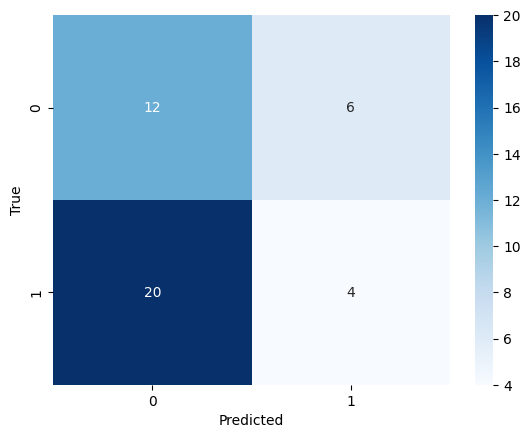

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(test_ds)
y_true = test_df["label"].to_numpy()
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_true, y_pred, target_names=["misinfo", "not_misinfo"]))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
import gc, torch
from accelerate.state import AcceleratorState

# Clean up previous states
gc.collect()
torch.cuda.empty_cache()
AcceleratorState._reset_state()


In [ ]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

args = TrainingArguments(
    output_dir="./results_tuned",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./results_tuned",
    eval_strategy="epoch",           # ✅ older versions use eval_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,                # gradual warmup
    lr_scheduler_type="cosine",      # smooth decay
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"                 # disables wandb/tensorboard
)


In [ ]:
from accelerate.state import AcceleratorState
AcceleratorState._reset_state()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.679669
2,No log,0.594986
3,No log,0.588191
4,No log,0.621111
5,No log,0.589455


TrainOutput(global_step=150, training_loss=0.6251106770833333, metrics={'train_runtime': 410.3241, 'train_samples_per_second': 5.752, 'train_steps_per_second': 0.731, 'total_flos': 274919752181760.0, 'train_loss': 0.6251106770833333, 'epoch': 5.0})

In [ ]:
from googletrans import Translator
translator = Translator()

def back_translate(text, lang='de'):
    try:
        return translator.translate(translator.translate(text, dest=lang).text, dest='en').text
    except:
        return text


In [ ]:
df_aug_syn = df_full.copy()
df_aug_syn["text_cleaned"] = df_aug_syn["text_cleaned"].apply(lambda t: " ".join(aug.augment(t)))
df_bt = df_full.copy()
df_bt["text_cleaned"] = df_bt["text_cleaned"].apply(back_translate)

df_expanded = pd.concat([df_full, df_aug_syn, df_bt], ignore_index=True)
df_expanded.to_csv("data_processed/full_expanded.csv", index=False)


NameError: name 'aug' is not defined

In [ ]:
# Re-import and initialize synonym augmenter
from nlpaug.augmenter.word import SynonymAug

# Create augmenter (WordNet-based synonym replacement)
aug = SynonymAug(aug_src='wordnet')


In [ ]:
df_aug_syn = df_full.copy()
df_aug_syn["text_cleaned"] = df_aug_syn["text_cleaned"].apply(lambda t: " ".join(aug.augment(t)))

df_bt = df_full.copy()
df_bt["text_cleaned"] = df_bt["text_cleaned"].apply(back_translate)

df_expanded = pd.concat([df_full, df_aug_syn, df_bt], ignore_index=True)
df_expanded.to_csv("data_processed/full_expanded.csv", index=False)

print("✅ Expanded dataset saved:", len(df_expanded))


✅ Expanded dataset saved: 417


In [ ]:
df_aug_syn = df_full.copy()
df_aug_syn["text_cleaned"] = df_aug_syn["text_cleaned"].apply(lambda t: " ".join(aug.augment(t)))
df_bt = df_full.copy()
df_bt["text_cleaned"] = df_bt["text_cleaned"].apply(back_translate)

df_expanded = pd.concat([df_full, df_aug_syn, df_bt], ignore_index=True)
df_expanded.to_csv("data_processed/full_expanded.csv", index=False)


In [ ]:
args.num_train_epochs = 8
args.load_best_model_at_end = True
args.metric_for_best_model = "eval_loss"
args.save_strategy = "epoch"


In [ ]:
callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]


In [ ]:
from torch.nn import CrossEntropyLoss
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = CrossEntropyLoss(weight=torch.tensor([1.3, 1.0]).to(device))


In [ ]:
for lr in [3e-5, 2e-5, 1e-5]:
    args.learning_rate = lr
    trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.609528
2,No log,0.604793
3,No log,0.656371
4,No log,0.639461


Epoch,Training Loss,Validation Loss
1,No log,0.630865
2,No log,0.630583
3,No log,0.640975
4,No log,0.610593
5,No log,0.607332
6,No log,0.622441
7,No log,0.657313


Epoch,Training Loss,Validation Loss
1,No log,0.647876
2,No log,0.718281
3,No log,0.766517


In [ ]:
learning_rate = 2e-5
num_train_epochs = 8
eval_strategy = "epoch"
save_strategy = "epoch"
EarlyStoppingCallback(patience=2)


NameError: name 'EarlyStoppingCallback' is not defined

In [ ]:
trainer.save_model("./covid_misinfo_best")
tokenizer.save_pretrained("./covid_misinfo_best")


NameError: name 'trainer' is not defined

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


NameError: name 'model' is not defined

In [ ]:
!pip install -U transformers datasets nlpaug sentencepiece googletrans==4.0.0-rc1


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.3 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=872598d15db750f0b68280a17b08f8c95ea6887c5a5acfa34b79fc98713a68bf
  Store

In [ ]:
df = pd.read_csv("data_processed/full_expanded.csv")  # or whichever you last used
label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)


NameError: name 'pd' is not defined

In [ ]:
import pandas as pd



In [ ]:
df = pd.read_csv("data_processed/full_expanded.csv")  # or whichever you last used
label2id = {"misinfo": 0, "not_misinfo": 1}
df["label"] = df["label_simplified"].map(label2id)


FileNotFoundError: [Errno 2] No such file or directory: 'data_processed/full_expanded.csv'

In [ ]:
!ls data_processed


ls: cannot access 'data_processed': No such file or directory


In [ ]:
import os, pandas as pd
os.makedirs("data_processed", exist_ok=True)

# Recreate your base dataset
df_full = pd.read_csv("data_raw/covmis_stance.csv")

# Simplify and clean again (same as before)
def simplify_label(stance):
    stance = str(stance).lower()
    if stance == "favor":
        return "misinfo"
    elif stance in ["against", "neither"]:
        return "not_misinfo"
    return None

def clean_text(text):
    import re
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df_full["label_simplified"] = df_full["label"].apply(simplify_label)
df_full["text_cleaned"] = df_full["mis"].apply(clean_text)
df_full = df_full.dropna(subset=["label_simplified"])

# Save again
df_full.to_csv("data_processed/full_labels.csv", index=False)
print("✅ Saved:", len(df_full), "samples -> data_processed/full_labels.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'data_raw/covmis_stance.csv'

In [ ]:
/content/covmis_stance.csv


NameError: name 'content' is not defined

In [ ]:
df_full = pd.read_csv("/content/covmis_stance.csv")


FileNotFoundError: [Errno 2] No such file or directory: '/content/covmis_stance.csv'